# Stage 6g — aggregation diagnostics for Figures 3 and 4

Two questions raised while reviewing the revised figures:

1. **Figure 3** shows apparent performance drops mid-optimization. Outlier seeds, or real?
2. **Figure 4**'s `Opt. Priority 1 → Priority 1` cell shows a *drop*, on the diagonal. Aggregation artifact, or real?

Everything here is post-processing of artifacts already on disk. Run
`python scripts/6g_aggregation_statistics.py` first to write the caches this notebook reads.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import utils_inverse

%load_ext autoreload
%autoreload 2

OUT = 'data/SI_results/aggregation_stats'
fig3 = pickle.load(open(f'{OUT}/fig3_aggregation.pkl', 'rb'))
fig4 = pickle.load(open(f'{OUT}/fig4_aggregation.pkl', 'rb'))
AGENTS = ['CO2', 'CH4', 'N2O', 'Sulfur', 'BC']

/workspaces/Emulator_Training_Data/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. First: how much of Figure 3's instability was ever emulator error?

Before Stage 1a the figure plotted the recorded objective, `NRMSE + smoothness_weight · Σ(ΔU)²`,
on an axis labelled NRMSE. The penalty depends only on the emissions profile, so a *roughening*
profile drives it up even while emulator error falls — which reads on the figure as the optimizer
losing skill when it is not.

This has to be settled before interpreting any remaining bump.

In [2]:
pd.read_csv(f'{OUT}/fig3_penalty_contamination.csv').set_index('agent')

,smoothness_weight,raw_max_rel_bump_pct,corrected_max_rel_bump_pct,raw_n_rises,corrected_n_rises,raw_final,corrected_final
agent,,,,,,,
CO2,0.000001,1.692,1.756,66,68,0.037952,0.036620
CH4,0.000000,-0.000,-0.000,0,0,0.016853,0.016853
N2O,0.000003,23.198,2.621,16,22,0.032025,0.028773
Sulfur,0.000000,0.000,0.000,1,1,0.014477,0.014477
BC,0.000030,58.103,0.758,102,155,0.018460,0.014446


**The two largest apparent drops were almost entirely the regularizer.** BC's 58% bump is 0.76% in
true NRMSE (98.7% of it was penalty); N2O's 23% is 2.6% (89% penalty). CO2 is unchanged, and CH4 and
Sulfur were never affected — their tuned `smoothness_weight` is 0.

Note the rise *count* goes **up** after correction while the magnitude collapses: removing a large,
smoothly-growing penalty term exposes many tiny wiggles in the error term. Those are invisible at
this scale — count alone is a misleading statistic here, which is why the census below reports
magnitude alongside it.

This is the same mechanism as the Figure 5 spikiness finding, seen from a different angle: the
penalty grows because the profile roughens.

## 2. Figure 3 — mean vs. median vs. percentile bands

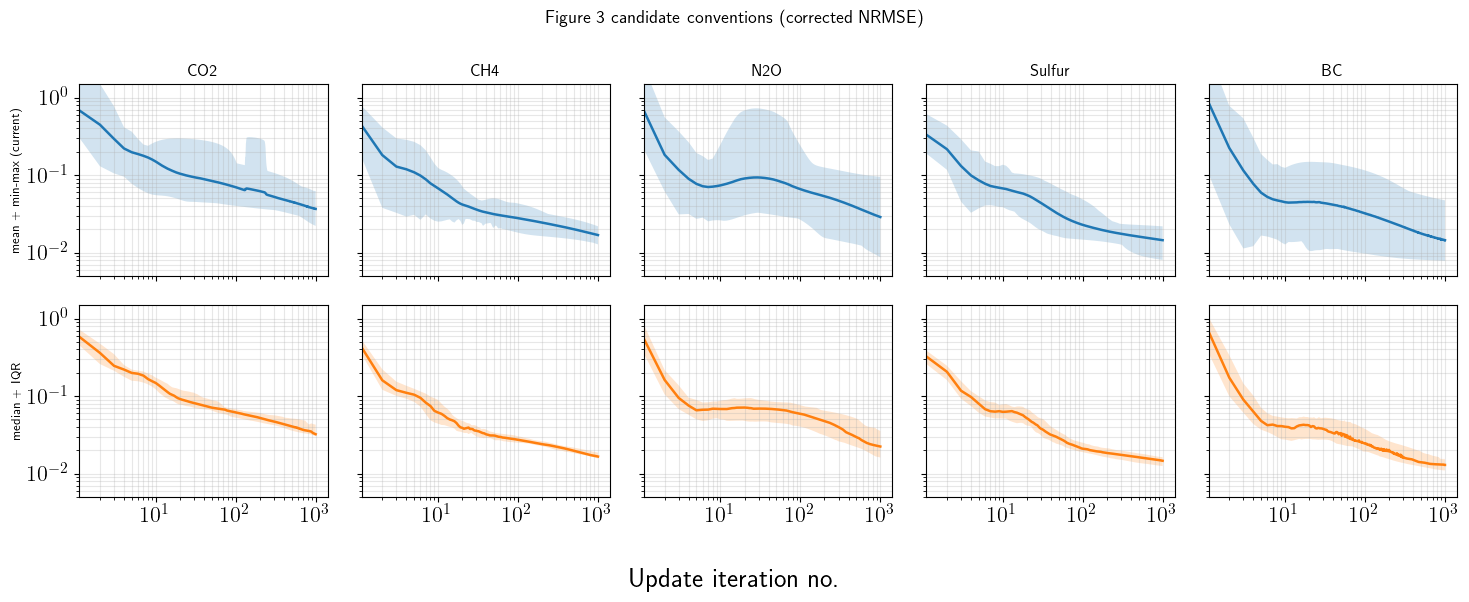

In [3]:
def _stack(agent):
    return fig3[agent]['aggregations']

def compare_aggregations(agents=AGENTS, figsize=(15, 6)):
    """Each agent under the current convention (mean + min-max) and a robust one
    (median + IQR). Same axes/scaling as utils_plotting.plot_rmse_comparison_single
    so the comparison is like-for-like."""
    fig, axes = plt.subplots(2, len(agents), figsize=figsize, sharex=True, sharey=True)
    for j, agent in enumerate(agents):
        a = _stack(agent)
        x = np.arange(len(a['mean']))
        for i, (line, lo, hi, name) in enumerate([
            ('mean', 'min', 'max', 'mean + min-max (current)'),
            ('median', 'p25', 'p75', 'median + IQR'),
        ]):
            ax = axes[i, j]
            ax.loglog(x, a[line], lw=1.8, color='C0' if i == 0 else 'C1')
            ax.fill_between(x, a[lo], a[hi], alpha=0.2,
                            color='C0' if i == 0 else 'C1', linewidth=0)
            ax.set_xlim(left=1.1); ax.set_ylim([0.005, 1.5])
            ax.grid(True, alpha=0.3, which='both')
            if i == 0:
                ax.set_title(agent, fontsize=12)
            if j == 0:
                ax.set_ylabel(name, fontsize=9)
    fig.supxlabel('Update iteration no.')
    fig.suptitle('Figure 3 candidate conventions (corrected NRMSE)', fontsize=13)
    fig.tight_layout()
    return fig

_ = compare_aggregations()
plt.show()

In [4]:
pd.read_csv(f'{OUT}/fig3_aggregation.csv').pivot(
    index='agent', columns='aggregation',
    values=['final', 'n_rises_total', 'max_rel_bump_pct', 'max_rel_bump_late_pct'])

final           n_rises_total        max_rel_bump_pct         \
aggregation      mean    median          mean median             mean median   
agent                                                                          
BC           0.014446  0.012946         155.0  209.0            0.758  6.347   
CH4          0.016853  0.016609           0.0    5.0           -0.000  1.200   
CO2          0.036620  0.032231          68.0   64.0            1.756  0.179   
N2O          0.028773  0.022370          22.0   18.0            2.621  2.744   
Sulfur       0.014477  0.014649           1.0    4.0            0.000  1.352   

            max_rel_bump_late_pct         
aggregation                  mean median  
agent                                     
BC                          0.757  6.347  
CH4                        -0.025  1.200  
CO2                         1.756  0.179  
N2O                         0.800  0.133  
Sulfur                     -0.015 -0.008

In [5]:
# Is each agent's worst late bump concentrated in a few seeds, or shared?
rows = []
for a in AGENTS:
    att = fig3[a]['late_bump_attribution']
    if att:
        rows.append({'agent': a, 'iteration': att['iteration'],
                     'seeds_rising': f"{att['n_seeds_rising']}/{att['n_seeds']}",
                     'top_seed_share_pct': round(att['top_seed_share'] * 100, 1),
                     'per_seed_rises_median': int(np.median(fig3[a]['per_seed_rises'])),
                     'per_seed_rises_max': max(fig3[a]['per_seed_rises'])})
pd.DataFrame(rows).set_index('agent')

,iteration,seeds_rising,top_seed_share_pct,per_seed_rises_median,per_seed_rises_max
agent,,,,,
CO2,130,2/50,108.9,2,285
CH4,997,0/50,NaN,15,31
N2O,20,33/50,33.0,23,41
Sulfur,995,0/50,NaN,5,21
BC,54,2/50,158.3,16,782


**"Use the median" is not a general fix — it depends on the agent.**

| agent | what the bumps are | does the median help? |
|---|---|---|
| CO2 | 2 of 50 seeds (worst seed supplies >100% of the mean's rise) | **yes** — max bump 1.8% → 0.2% |
| N2O | **shared**: 33 of 50 seeds rise together, worst supplies 33% | **no** — real early-transient behaviour |
| BC | 2 of 50 seeds | **no, it hurts** — median's max bump 6.3% vs. the mean's 0.8% |
| CH4, Sulfur | essentially none | nothing to fix |

BC is the instructive case: its mean is dominated by smooth high-error seeds, while the median tracks
wigglier low-error ones, so the robust statistic is the *noisier* line. N2O's bumps are genuine
optimizer behaviour concentrated in the first ~20 iterations and should be explained, not hidden.

**On "does median ± standard deviation have meaning?"** — no. Standard deviation is the dispersion
natural to the mean; a median pairs with the IQR, MAD, or explicit percentiles. These distributions
are right-skewed (mean > median at essentially every iteration), so a symmetric ±σ band around a
median misrepresents both tails, and on a log axis its lower edge can go non-positive and simply fail
to render — the reason the current figure uses min–max. Median + IQR keeps both bounds strictly
positive and is robust, so it is the like-for-like replacement.

## 3. Figure 4 — does the Priority-1 drop survive a robust aggregation?

In [6]:
df4 = pd.read_csv(f'{OUT}/fig4_aggregation.csv')
diag = df4[df4.apply(lambda r: r['train_scenario'] == f"Opt. {r['test_scenario']}", axis=1)]
diag.set_index(['panel', 'train_scenario'])[
    ['mean_of_ratios', 'median_of_ratios', 'ratio_of_medians',
     'iqr_of_ratios', 'n_negative', 'median_abs_diff']]

mean_of_ratios  median_of_ratios  ratio_of_medians  \
panel      train_scenario                                                       
co2_only   Opt. Tier 1            33.4839           35.8124           41.3057   
           Opt. Tier 2            31.1552           34.3425           34.6848   
           Opt. DECK              34.0191           44.8634           44.6818   
           Opt. CS3               82.6066           89.9419           89.0198   
all_agents Opt. Tier 1           -29.8128          -20.7693          -16.6739   
           Opt. Tier 2            28.6402           31.5997           35.4089   
           Opt. DECK              78.4409           79.4692           79.4279   
           Opt. CS3               97.4999           97.9751           98.0483   

                           iqr_of_ratios  n_negative  median_abs_diff  
panel      train_scenario                                              
co2_only   Opt. Tier 1           17.4769           4           0.0178  
           Opt. Tier 2            7.9937           1           0.0401  
           Opt. DECK             31.7745           5           0.0215  
           Opt. CS3              12.0739           0           0.0437  
all_agents Opt. Tier 1           60.9946          31          -0.0148  
           Opt. Tier 2           22.8595           6           0.0579  
           Opt. DECK              9.0208           0           0.4694  
           Opt. CS3               1.8146           0           0.5052

The on-diagonal cells. Every one is solidly positive **except the multi-agent panel's Priority 1**,
which is negative under all three aggregations with 31 of 50 seeds negative.

Note this is **specific to the multi-agent panel**: the CO2-only panel's same cell is **+33.5% mean /
+35.8% median**, with only 4 of 50 seeds negative. So the phenomenon is not "Priority 1 is hard" —
it is something about the multi-agent optimization.

In [7]:
# Priority-1 column, per scenario, both panels.
dfp = pd.read_csv(f'{OUT}/fig4_priority1_decomposition.csv')
dfp.pivot(index='scenario', columns='panel',
          values=['median_baseline_nrmse', 'median_optimized_nrmse',
                  'median_of_ratios', 'median_abs_diff'])

median_baseline_nrmse           median_optimized_nrmse            \
panel                 all_agents  co2_only             all_agents  co2_only   
scenario                                                                      
H-ext                   0.007054  0.005926               0.044580  0.082009   
L                       0.072951  0.045084               0.100616  0.011763   
M                       0.022661  0.027543               0.022974  0.007584   
ML                      0.025447  0.029668               0.022607  0.008900   
VLHO                    0.100831  0.044332               0.049151  0.015611   
VLLO-ext                0.072456  0.084136               0.108420  0.018579   
historical              0.187904  0.119602               0.149438  0.006550   

           median_of_ratios              median_abs_diff            
panel            all_agents     co2_only      all_agents  co2_only  
scenario                                                            
H-ext           -553.433940 -1246.733298       -0.039491 -0.075333  
L                -47.265288    73.440560       -0.030309  0.032671  
M                -20.644750    72.295947       -0.004058  0.019055  
ML                 8.100002    69.832978        0.001745  0.020280  
VLHO              42.347283    69.211165        0.049084  0.028580  
VLLO-ext         -50.042939    76.474901       -0.032633  0.061818  
historical        27.708546    93.841268        0.042281  0.108157

### Two different things are going on in the two panels

**CO2-only** — a pure metric artifact. `H-ext` reads **−1247%**, but only because the baseline is
near-perfect there (NRMSE 0.0059): the optimized emulator's 0.0820 is a small *absolute* miss. Every
other scenario improves by 66–94%, and the cell nets out **positive**. The percentage is doing the
damage, not the method.

**Multi-agent** — partly real. `H-ext` is again inflated (−553% off a 0.0071 baseline), but `L`
(−47%), `VLLO-ext` (−50%) and `M` (−21%) degrade in **absolute** NRMSE too — the `median_abs_diff`
column is genuinely negative for four of seven scenarios. That cannot be explained away by the
denominator.

So the honest answer to question 2 has two parts:
1. The **magnitude** shown on the bar is exaggerated by percent-change against a near-zero baseline.
2. A **real** degradation remains underneath it, specific to the multi-agent case.

### A likely cause, and how to test it

The baseline is trained on all seven Priority-1 scenarios, so this is the one cell where it has no
generalization gap — a structural advantage no other column gives it.

But that applies equally to the CO2-only panel, which is positive. What differs is that the
**multi-agent optimized emissions profiles are white-noise-spiky** (`smoothness_weight = 0`, 21–51%
of their power above 0.25 cyc/yr) while the CO2-only profiles are smooth. An emulator trained on a
spiky synthetic scenario plausibly generalizes worse to the smooth *real* Priority-1 scenarios.

That predicts the Stage 6h low-pass ablation should **recover** part of this cell — a direct,
falsifiable link between phenomena 2 and 3.

In [8]:
# Full Figure 4 grid under each aggregation, for the record.
for panel in ['co2_only', 'all_agents']:
    sub = df4[df4['panel'] == panel]
    print(f'--- {panel}: mean-of-ratios (what the figure plots today) ---')
    display(sub.pivot(index='test_scenario', columns='train_scenario',
                      values='mean_of_ratios').round(1))
    print(f'--- {panel}: median-of-ratios ---')
    display(sub.pivot(index='test_scenario', columns='train_scenario',
                      values='median_of_ratios').round(1))

--- co2_only: mean-of-ratios (what the figure plots today) ---


train_scenario,Opt. All,Opt. CS3,Opt. DECK,Opt. Tier 1,Opt. Tier 2
test_scenario,,,,,
Avg.,31.0,-8.5,-51.3,27.8,24.2
CS3,70.1,82.6,-27.2,73.0,51.0
DECK,-22.7,-82.4,34.0,-41.7,-35.7
Tier 1,32.7,-32.5,-141.5,33.5,19.4
Tier 2,30.1,0.7,-13.1,25.8,31.2


--- co2_only: median-of-ratios ---


train_scenario,Opt. All,Opt. CS3,Opt. DECK,Opt. Tier 1,Opt. Tier 2
test_scenario,,,,,
Avg.,34.6,0.5,-47.6,32.6,31.8
CS3,80.0,89.9,-19.3,80.5,66.5
DECK,-8.2,-55.0,44.9,-23.3,-18.2
Tier 1,36.4,-24.1,-128.4,35.8,27.8
Tier 2,32.0,6.7,-10.9,27.8,34.3


--- all_agents: mean-of-ratios (what the figure plots today) ---


train_scenario,Opt. All,Opt. CS3,Opt. DECK,Opt. Tier 1,Opt. Tier 2
test_scenario,,,,,
Avg.,33.5,-67.7,-817.6,11.4,-25.3
CS3,75.2,97.5,-319.6,49.1,55.4
DECK,47.8,-21.4,78.4,15.3,26.4
Tier 1,-77.0,-508.8,-4203.3,-29.8,-443.4
Tier 2,21.4,-87.9,-869.1,-21.6,28.6


--- all_agents: median-of-ratios ---


train_scenario,Opt. All,Opt. CS3,Opt. DECK,Opt. Tier 1,Opt. Tier 2
test_scenario,,,,,
Avg.,37.1,-66.9,-784.1,11.8,-24.5
CS3,79.9,98.0,-244.1,54.4,60.8
DECK,51.5,-17.6,79.5,19.9,28.3
Tier 1,-59.0,-502.3,-3975.6,-20.8,-407.7
Tier 2,23.2,-79.9,-918.8,-16.9,31.6


## Summary

**Figure 3.** The two largest apparent drops (BC 58%, N2O 23%) were the smoothness penalty, not
emulator error, and are gone now that the figure reports true NRMSE. What remains is small (<3%) and
agent-specific: CO2's is 2 seeds of 50 and the median removes it; N2O's is shared across 33 of 50
seeds and is real; BC's median is *worse* than its mean. Recommendation: median + IQR, with N2O's
early transient described rather than hidden — but the choice is worth eyeballing in §2 first.

**Figure 4.** The Priority-1 drop is real in the multi-agent panel and survives every robust
aggregation (31/50 seeds negative), though the bar overstates it because percent change against a
near-zero `H-ext` baseline is unbounded below. The CO2-only panel's same cell is positive, which
points at the multi-agent profiles' high-frequency content as the cause — testable by the Stage 6h
low-pass ablation.